# Introudction
This notebook shows how to open and understand the dataset.
It also shows how to prepare the results submission.
You can run this script as a Python script or as a Jupyter notebook.

In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

Dataset paths

In [3]:
DATASET_DIR = Path('./data')

In [4]:
HSI_AIRBORNE_DIR = DATASET_DIR / 'train' / 'hsi_airborne'
HSI_SATELLITE_DIR = DATASET_DIR / 'train' / 'hsi_satellite'
MSI_SATELLITE_TRAIN_DIR = DATASET_DIR / 'train' / 'msi_satellite'
MSI_SATELLITE_TEST_DIR = DATASET_DIR / 'test' / 'msi_satellite'

In [5]:
GT_TRAIN_CSV_PATH = DATASET_DIR / 'train_gt.csv'
# %% Load the ground truth measurements
gt_train_df = pd.read_csv(GT_TRAIN_CSV_PATH)
gt_train_df.head()
column_names = ['Fe', 'Zn', 'B', 'Cu', 'S', 'Mn']

`gt_df` contains the ground truth measurements for the training dataset.
For each sample_index we have 6 ground-truth measurements: Fe, Zn, B, Cu, S, Mn.

# Dsiplaying example data
One field for a single multispectral band, for all 3 modalities.

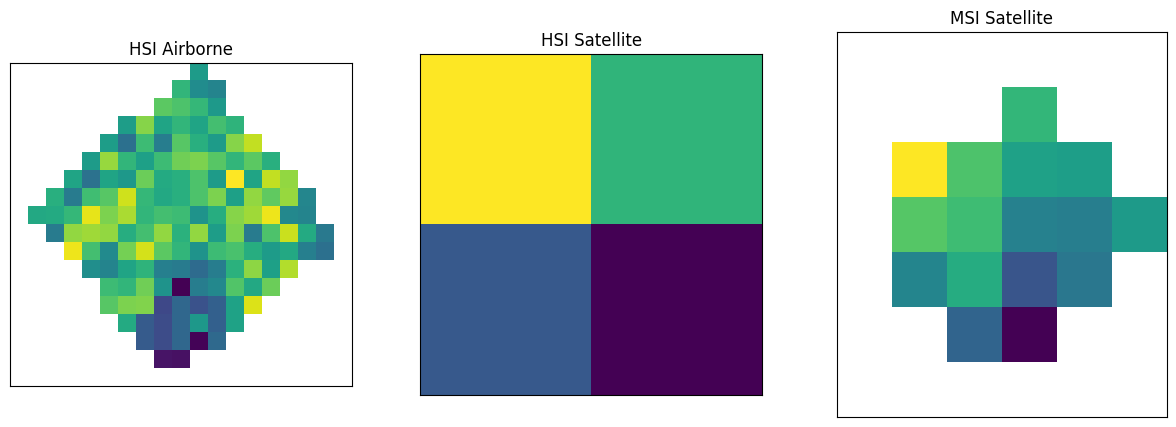

In [27]:
selected_index = 67
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
BAND_NUMBER = 7
with np.load(HSI_AIRBORNE_DIR / f'{selected_index:04}.npz') as npz:
    arr = np.ma.MaskedArray(**npz)
    axs[0].imshow(arr[BAND_NUMBER, :, :])
    axs[0].set_title('HSI Airborne')
    axs[0].set_xticks([])
    axs[0].set_yticks([])

with np.load(HSI_SATELLITE_DIR / f'{selected_index:04}.npz') as npz:
    arr = np.ma.MaskedArray(**npz)
    axs[1].imshow(arr[BAND_NUMBER, :, :].data)
    axs[1].set_title('HSI Satellite')
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    
with np.load(MSI_SATELLITE_TRAIN_DIR / f'{selected_index:04}.npz') as npz:
    arr = np.ma.MaskedArray(**npz)
    axs[2].imshow(arr[BAND_NUMBER, :, :])
    axs[2].set_title('MSI Satellite')
    axs[2].set_xticks([])
    axs[2].set_yticks([])

plt.savefig('/home/miki/Obrazy/images.svg')

# Checking resolution range for each source type

# Displaying spectral curve for a selected field

In [7]:
selected_index = 377

In [8]:
with np.load(HSI_SATELLITE_DIR / f'{selected_index:04}.npz') as npz:
    arr = np.ma.MaskedArray(**npz)

In [9]:
pixel_0 = arr.data[:, 0, 0]

Text(0.5, 1.0, 'Spectral curve for a selected pixel')

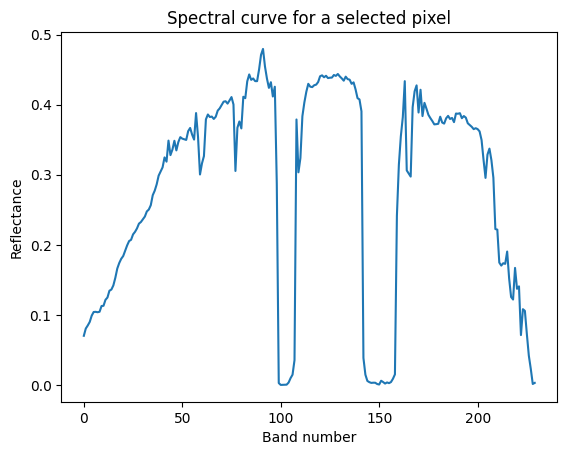

In [10]:
plt.plot(pixel_0)
plt.xlabel('Band number')
plt.ylabel('Reflectance')
plt.title('Spectral curve for a selected pixel')

%% [markdown]


<br>
# Generating baseline solution<br>
Baseline solution is used to calculate the performance of the final model.<br>


In [11]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0
    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self
    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)

%% [markdown]


<br>
# Load data for satellite multispectral images<br>


In [12]:
def load_msi_data(directory):
    files = sorted(directory.glob('*.npz'))
    msi_data = []
    for file in enumerate(files):
        file_name = file[1]
        with np.load(file_name) as npz:
            arr = np.ma.MaskedArray(**npz)
            mean_pixel = np.mean(arr, axis=(1, 2))  # mean over all pixels
            msi_data.append(mean_pixel)
    msi_data = np.array(msi_data)
    return msi_data

In [13]:
print(f'Loading data from {MSI_SATELLITE_TRAIN_DIR} and {MSI_SATELLITE_TEST_DIR}')
X_train_all = load_msi_data(MSI_SATELLITE_TRAIN_DIR)
X_test_all = load_msi_data(MSI_SATELLITE_TEST_DIR)
y_train_all = gt_train_df[column_names].values

Loading data from data/train/msi_satellite and data/test/msi_satellite


In [14]:
print(f'X_train shape: {X_train_all.shape}')
print(f'Y_train shape: {y_train_all.shape}')
print(f'X_test shape: {X_test_all.shape}')

X_train shape: (1876, 12)
Y_train shape: (1876, 6)
X_test shape: (1888, 12)


%% [markdown]


<br>
# Calculating the metric<br>
Use part of the training data to train the model and the rest to calculate the metric.<br>


In [15]:
X_train = X_train_all[:1300]
y_train = y_train_all[:1300]

In [16]:
X_test = X_train_all[1300:]
y_test = y_train_all[1300:]

Fit the baseline model

In [17]:
baseline_reg = BaselineRegressor()
baseline_reg = baseline_reg.fit(X_train, y_train)
baseline_predictions = baseline_reg.predict(X_test)

Generate baseline values to be used in score computation

In [18]:
baselines = np.mean((y_test - baseline_predictions) ** 2, axis=0)

Generate predictions slightly different from baseline predictions

In [19]:
np.random.seed(0)
predictions = np.zeros_like(y_test)
for column_index in range(predictions.shape[1]):
    class_mean_value = baseline_reg.mean[column_index]
    predictions[:, column_index] = np.random.uniform(low=class_mean_value - class_mean_value * 0.2,
                                                     high=class_mean_value + class_mean_value * 0.2,
                                                     size=len(predictions))

Calculate MSE for each class

In [20]:
mse = np.mean((y_test - predictions) ** 2, axis=0)

Calculate the score for each class individually

In [21]:
scores = mse / baselines

Calculate the final score

In [22]:
final_score = np.mean(scores)

In [23]:
for score, class_name in zip(scores, column_names):
    print(f"Class {class_name} score: {score}")

Class Fe score: 1.157426856706684
Class Zn score: 1.059032793104139
Class B score: 1.1648081081649437
Class Cu score: 1.491160760393519
Class S score: 1.026155672977328
Class Mn score: 1.2956695787511288


In [24]:
print(f"Final score: {final_score}")

Final score: 1.1990422950162907


%% [markdown]


<br>
# Prepare the submission for test set<br>


In [25]:
baseline_predictions_test = baseline_reg.predict(X_test_all)
submission = pd.DataFrame(data=baseline_predictions_test, columns=column_names)
submission.to_csv("submission.csv", index_label="sample_index")

%%